## IMPORTS

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import pandas as pd
import os
import duckdb
from traj_ps.backends.bayes import BayesianTrajPS, BayesConfig
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve
)
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from scipy.stats import wilcoxon
import warnings
warnings.filterwarnings('ignore')

# Import shared utility functions
from notebook_utils import (
    aggregate_vitals_labs, drop_high_missing_columns, impute_features,
    plot_trajectory_distribution, plot_boxplots_with_stats,
    plot_roc_pr_curves, print_statistical_comparisons, train_repeated_cv
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports successful")


✓ Imports successful


## LOAD

In [2]:
# Connect to MIMIC-III DuckDB
db_path = '../../data/mimic/mimiciii.duckdb'
conn = duckdb.connect(db_path, read_only=True)

print(f"✓ Connected to MIMIC-III database: {db_path}")

✓ Connected to MIMIC-III database: ../../data/mimic/mimiciii.duckdb


In [3]:
# Load mechanically ventilated patients
hadm_query = """
WITH ventilated_patients AS (
    SELECT DISTINCT
        i.hadm_id::INTEGER AS hadm_id,
        MIN(ce.charttime::TIMESTAMP) as vent_start
    FROM chartevents ce
    INNER JOIN icustays i ON ce.icustay_id = i.icustay_id
    WHERE 
        ce.itemid IN (720, 223849)  -- Ventilator mode
        AND ce.value IS NOT NULL
    GROUP BY i.hadm_id
)
SELECT 
    i.subject_id::INTEGER AS subject_id,
    i.hadm_id::INTEGER AS hadm_id,
    a.admittime::TIMESTAMP as admittime,      -- Hospital admission time
    a.dischtime::TIMESTAMP as dischtime,      -- Hospital discharge time
    vp.vent_start::TIMESTAMP as vent_start,   -- Ventilation start time
    CAST(a.dischtime::DATE - a.admittime::DATE AS REAL) as los_days,  -- Hospital LOS
    p.gender,
    CAST((a.admittime::DATE - p.dob::DATE) / 365.25 AS INT) as age,
    a.hospital_expire_flag::INT as hospital_expire_flag,
    a.discharge_location
FROM icustays i
INNER JOIN patients p ON i.subject_id = p.subject_id
INNER JOIN admissions a ON i.hadm_id = a.hadm_id
INNER JOIN ventilated_patients vp ON i.hadm_id = vp.hadm_id
WHERE 
    -- Filter adults
    CAST((a.admittime::DATE - p.dob::DATE) / 365.25 AS INT) BETWEEN 18 AND 90
    -- Minimum hospital stay
    AND CAST(a.dischtime::DATE - a.admittime::DATE AS REAL) >= 2.0
"""

hadm_df = conn.execute(hadm_query).fetchdf()
hadm_df.columns = hadm_df.columns.str.lower()
print(f"\n✓ Loaded {len(hadm_df):,} mechanically ventilated admissions")
print(f"  Unique patients: {hadm_df['subject_id'].nunique():,}")
print(f"  Mean hospital LOS: {hadm_df['los_days'].mean():.1f} days")
print(f"  Mortality: {hadm_df['hospital_expire_flag'].mean():.1%}")


✓ Loaded 25,340 mechanically ventilated admissions
  Unique patients: 20,132
  Mean hospital LOS: 15.2 days
  Mortality: 15.4%


In [4]:
# Sample subset
hadm_subset = hadm_df.sort_values('admittime').drop_duplicates(subset=['subject_id'])['hadm_id'].sample(min(5000, hadm_df['subject_id'].nunique()), random_state=920).tolist()
hadm_df = hadm_df[hadm_df['hadm_id'].isin(hadm_subset)]

print(f"✓ Using {hadm_df['hadm_id'].nunique():,} admissions for analysis")

✓ Using 5,000 admissions for analysis


In [5]:
# Load metadata for vitals and labs
vital_meta = pd.read_csv('../../data/mimic/vital_metadata.csv')
labs_meta = pd.read_csv('../../data/mimic/labs_metadata.csv')

print(f"✓ Loaded metadata: {len(vital_meta):,} vital items, {len(labs_meta):,} lab items")

vital_items = vital_meta['itemid'].to_list()
lab_items = labs_meta['itemid'].to_list()

✓ Loaded metadata: 43 vital items, 27 lab items


In [6]:
# Load PaO2/FiO2 ratio (P/F ratio) - key weaning predictor
# Note: PaO2/FiO2 are in labevents (blood gas measurements)
# Lower values = worse oxygenation, <200 = ARDS

bg_query = """
SELECT 
    le.hadm_id::INTEGER AS hadm_id,
    le.charttime::TIMESTAMP AS charttime,
    EXTRACT(EPOCH FROM (le.charttime::TIMESTAMP - a.admittime::TIMESTAMP)) / 86400.0 as time_days,
    MAX(CASE WHEN le.itemid = 50821 THEN CAST(le.valuenum AS REAL) END) as pao2,
    MAX(CASE WHEN le.itemid = 50816 THEN CAST(le.valuenum AS REAL) END) as fio2
FROM labevents le
INNER JOIN admissions a ON le.hadm_id = a.hadm_id
WHERE 
    le.itemid IN (50821, 50816)
    AND le.hadm_id::INTEGER IN {hadm_ids}
    AND le.charttime::TIMESTAMP BETWEEN a.admittime::TIMESTAMP AND a.dischtime::TIMESTAMP
GROUP BY le.hadm_id, le.charttime, a.admittime
HAVING MAX(CASE WHEN le.itemid = 50821 THEN CAST(le.valuenum AS REAL) END) IS NOT NULL
    AND MAX(CASE WHEN le.itemid = 50816 THEN CAST(le.valuenum AS REAL) END) IS NOT NULL
"""

bg_df = conn.execute(bg_query.format(hadm_ids=tuple(hadm_subset))).fetchdf()
bg_df.columns = bg_df.columns.str.lower()

# Calculate P/F ratio
bg_df['pf_ratio'] = bg_df['pao2'] / bg_df['fio2'] * 100
bg_df = bg_df[(bg_df['pf_ratio'] >= 50) & (bg_df['pf_ratio'] <= 600)]

print(f"\n✓ Loaded {len(bg_df):,} blood gas measurements")
print(f"  Admissions with P/F ratio: {bg_df['hadm_id'].nunique():,}")
print(f"  Mean P/F ratio: {bg_df['pf_ratio'].mean():.0f}")


✓ Loaded 20,798 blood gas measurements
  Admissions with P/F ratio: 2,934
  Mean P/F ratio: 237


In [7]:
# Load vitals for general health status
vitals_query = """
SELECT chartevents.subject_id::INTEGER AS subject_id
    , chartevents.hadm_id::INTEGER AS hadm_id
    , chartevents.charttime::TIMESTAMP AS charttime
    , chartevents.itemid::INTEGER AS itemid
    , chartevents.valuenum::DOUBLE AS valuenum
      , admissions.admittime::TIMESTAMP AS admittime
        FROM chartevents
                 INNER JOIN admissions
                            ON chartevents.subject_id = admissions.subject_id
                                AND chartevents.hadm_id = admissions.hadm_id
                                AND chartevents.charttime::TIMESTAMP between
                                   (admissions.admittime::TIMESTAMP)
                                   AND (admissions.dischtime::TIMESTAMP)
                                AND itemid::INTEGER in {itemids}
                                AND chartevents.hadm_id::INTEGER in {hadm_ids}
      AND chartevents.error::INTEGER IS DISTINCT FROM 1 
"""

vitals_df = conn.execute(vitals_query.format(itemids=vital_items, hadm_ids=tuple(hadm_subset))).fetchdf()
vitals_df.columns = vitals_df.columns.str.lower()
print(f"\n✓ Loaded {len(vitals_df):,} vital signs")
print(f"  Admissions: {vitals_df['hadm_id'].nunique():,}")


✓ Loaded 6,461,793 vital signs
  Admissions: 5,000


In [8]:
# Load labs for general health status
labs_query = """
SELECT labevents.subject_id::INTEGER AS subject_id
      , labevents.hadm_id::INTEGER AS hadm_id
      , labevents.charttime::TIMESTAMP AS charttime
      , labevents.itemid::INTEGER AS itemid
      , labevents.valuenum::DOUBLE AS valuenum
      , admissions.admittime::TIMESTAMP AS admittime
FROM labevents
          INNER JOIN admissions
                    ON labevents.subject_id = admissions.subject_id
                        AND labevents.hadm_id = admissions.hadm_id
                        AND labevents.charttime::TIMESTAMP between
                            (admissions.admittime::TIMESTAMP)
                            AND (admissions.dischtime::TIMESTAMP)
                        AND itemid::INTEGER IN {itemids}
                        AND labevents.hadm_id::INTEGER IN {hadm_ids}
"""

labs_df = conn.execute(labs_query.format(itemids=lab_items, hadm_ids=tuple(hadm_subset))).fetchdf()
labs_df.columns = labs_df.columns.str.lower()
print(f"✓ Loaded {len(labs_df):,} lab values")
print(f"  Admissions: {labs_df['hadm_id'].nunique():,}")

✓ Loaded 1,387,145 lab values
  Admissions: 4,987


## PREPROCESS

In [ ]:
# # Merge with metadata and validate ranges
# vitals_df = vitals_df.merge(vital_meta, on='itemid', how='left')
# labs_df = labs_df.merge(labs_meta, on='itemid', how='left')

# # Remove invalid values
# vitals_df = vitals_df[vitals_df['valuenum'].between(vitals_df['min'], vitals_df['max'], inclusive='both')]
# labs_df = labs_df[labs_df['valuenum'].between(labs_df['min'], labs_df['max'], inclusive='both')]

# # Convert fahrenheit to celsius
# vitals_df.loc[vitals_df['units'] == 'F', 'valuenum'] = (vitals_df.loc[vitals_df['units'] == 'F', 'valuenum'] - 32) * 5.0/9.0
# vitals_df.loc[vitals_df['units'] == 'F', 'units'] = 'C'
# vitals_df.loc[vitals_df['feature name'] == 'TempF', 'feature name'] = 'TempC'

# print(f"✓ Validated vitals and labs against metadata ranges")

✓ Validated vitals and labs against metadata ranges


In [9]:
# Use shared utility function for standardized vitals/labs aggregation
vitals_labs_wide = aggregate_vitals_labs(
    vitals_df=vitals_df,
    labs_df=labs_df,
    vital_meta=vital_meta,
    labs_meta=labs_meta
)


print(f"\n✓ Processed vitals + labs with min/max/mean aggregation (using shared utilities):")
print(f"  Total daily observations: {len(vitals_labs_wide):,}")
print(f"  Total features: {len([c for c in vitals_labs_wide.columns if c not in ['hadm_id', 'time_day']])}")
print(f"  Example features: {list(vitals_labs_wide.columns[2:8])}")


✓ Processed vitals + labs with min/max/mean aggregation (using shared utilities):
  Total daily observations: 63,982
  Total features: 87
  Example features: ['BICARBONATE_min', 'BILIRUBIN_min', 'BUN_min', 'CHLORIDE_min', 'CREATININE_min', 'DiasBP_min']


In [13]:
vitals_labs_wide.head()

ALBUMIN_min  ANION GAP_min  \
hadm_id admittime           charttime                                
100011  2177-08-29 04:51:00 2177-08-29          NaN            9.0   
                            2177-08-30          NaN            NaN   
                            2177-08-31          2.5            9.0   
                            2177-09-01          2.4           10.0   
                            2177-09-02          NaN           11.0   

                                        BICARBONATE_min  BILIRUBIN_min  \
hadm_id admittime           charttime                                    
100011  2177-08-29 04:51:00 2177-08-29             23.0            NaN   
                            2177-08-30              NaN            NaN   
                            2177-08-31             26.0            NaN   
                            2177-09-01             27.0            NaN   
                            2177-09-02             25.0            NaN   

                                        BUN_min  CHLORIDE_min  CREATININE_min  \
hadm_id admittime           charttime                                           
100011  2177-08-29 04:51:00 2177-08-29     11.0         109.0             1.1   
                            2177-08-30      NaN         107.0             NaN   
                            2177-08-31     11.0         105.0             1.0   
                            2177-09-01      8.0         105.0             0.8   
                            2177-09-02      8.0         105.0             0.6   

                                        DiasBP_min  GLUCOSE_min  Glucose_min  \
hadm_id admittime           charttime                                          
100011  2177-08-29 04:51:00 2177-08-29        43.0        113.0        112.0   
                            2177-08-30        53.0        124.0        109.0   
                            2177-08-31        56.0        127.0        110.0   
                            2177-09-01        57.0        106.0         84.0   
                            2177-09-02        63.0        119.0        116.0   

                                        ...  POTASSIUM_mean  PT_mean  \
hadm_id admittime           charttime   ...                            
100011  2177-08-29 04:51:00 2177-08-29  ...        4.120000     16.4   
                            2177-08-30  ...        3.975000      NaN   
                            2177-08-31  ...        3.825000     16.1   
                            2177-09-01  ...        3.533333     14.0   
                            2177-09-02  ...        3.700000     13.5   

                                        PTT_mean  RespRate_mean  SODIUM_mean  \
hadm_id admittime           charttime                                          
100011  2177-08-29 04:51:00 2177-08-29      29.2      19.235294   138.600000   
                            2177-08-30       NaN      16.333333   138.333333   
                            2177-08-31      30.5      15.058824   137.500000   
                            2177-09-01      28.1      16.896552   139.500000   
                            2177-09-02      24.7      23.461538   139.333333   

                                         SpO2_mean  SysBP_mean  TempC_mean  \
hadm_id admittime           charttime                                        
100011  2177-08-29 04:51:00 2177-08-29   99.600000  124.257143   37.738889   
                            2177-08-30  100.000000  145.423077   37.863636   
                            2177-08-31   99.750000  149.714286   38.217593   
                            2177-09-01   99.200000  142.400000   38.069444   
                            2177-09-02   99.565217  146.521739   38.087302   

                                         WBC_mean  Weight_mean  
hadm_id admittime           charttime                           
100011  2177-08-29 04:51:00 2177-08-29  11.566667         74.1  
                            2177-08-30        NaN          NaN  
                            

In [11]:
# Use shared utility function for dropping high-missing columns
vitals_labs_clean, dropped_cols = drop_high_missing_columns(
    df=vitals_labs_wide,
    threshold=0.2,
)

# Use shared utility for imputation
# Identify column types for intelligent imputation
vital_features = [c for c in vitals_labs_clean.columns if any(v in c for v in ['HeartRate', 'BP', 'Temp', 'Resp', 'SpO2'])]
lab_features = [c for c in vitals_labs_clean.columns if any(l in c for l in ['CREATININE', 'LACTATE', 'WBC', 'PLATELET', 'BICARBONATE', 'GLUCOSE', 'SODIUM', 'POTASSIUM', 'HEMATOCRIT', 'HEMOGLOBIN'])]

vitals_labs_imputed = impute_features(
    df=vitals_labs_clean,
    hadm_col='hadm_id',
    vital_cols=vital_features,
    lab_cols=lab_features
)

# Reset index if needed
if vitals_labs_imputed.index.name == 'hadm_id':
    vitals_labs_imputed = vitals_labs_imputed.reset_index()

print(f"\n✓ Imputation and cleanup (using shared utilities):")
print(f"  Dropped {len(dropped_cols)} high-missing columns (>20%)")
print(f"  Remaining features: {len([c for c in vitals_labs_imputed.columns if c not in ['hadm_id']])}")
print(f"  Overall missing rate: {vitals_labs_imputed.isna().mean().mean():.2%}")



✓ Imputation and cleanup (using shared utilities):
  Dropped 48 high-missing columns (>20%)
  Remaining features: 39
  Overall missing rate: 4.58%


In [ ]:
# Calculate baseline P/F ratio (first 24h on ventilator)
# Merge with hadm_df to get vent_start timestamp
bg_df = bg_df.merge(hadm_df[['hadm_id', 'vent_start']], on='hadm_id', how='left')
bg_df['charttime'] = pd.to_datetime(bg_df['charttime'])

first_24h = bg_df[
    bg_df['charttime'] <= bg_df['vent_start'] + pd.Timedelta(hours=24)
]

baseline_pf = first_24h.groupby('hadm_id')['pf_ratio'].first().reset_index()
baseline_pf.columns = ['hadm_id', 'baseline_pf_ratio']

print(f"\nBaseline P/F ratio (first 24h):")
print(f"   Admissions with baseline: {len(baseline_pf):,}")
print(f"   Mean: {baseline_pf['baseline_pf_ratio'].mean():.0f}")
print(f"   Median: {baseline_pf['baseline_pf_ratio'].median():.0f}")


Baseline P/F ratio (first 24h):
   Admissions with baseline: 2,493
   Mean: 271
   Median: 260


In [ ]:
# Filter admissions with sufficient measurements
pf_counts = bg_df.groupby('hadm_id').size()
valid_hadm_ids = pf_counts[pf_counts >= 3].index

pf_filtered = bg_df[bg_df['hadm_id'].isin(valid_hadm_ids)]
hadm_final = hadm_df[hadm_df['hadm_id'].isin(valid_hadm_ids)].merge(
    baseline_pf, on='hadm_id', how='inner'
)

print(f"\nFiltering:")
print(f"   Admissions with ≥3 P/F measurements: {len(hadm_final):,}")


Filtering:
   Admissions with ≥3 P/F measurements: 1,763


In [14]:
# Create P/F ratio time series
pf_filtered['time_day'] = np.floor(pf_filtered['time_days']).astype(int)

pf_ts = pf_filtered[['hadm_id', 'time_days', 'time_day', 'pf_ratio']].merge(
    hadm_final[['hadm_id', 'baseline_pf_ratio', 'age', 'gender', 'hospital_expire_flag']].drop_duplicates(),
    on='hadm_id',
    how='left'
)

pf_ts['pf_improvement'] = pf_ts['pf_ratio'] - pf_ts['baseline_pf_ratio']

print(f"\nP/F Ratio Time Series:")
print(f"   Total measurements: {len(pf_ts):,}")
print(f"   Mean improvement: {pf_ts['pf_improvement'].mean():.0f}")


P/F Ratio Time Series:
   Total measurements: 22,557
   Mean improvement: 1


In [15]:
# Save
os.makedirs('../../results/mimic/ventilator', exist_ok=True)
pf_ts.to_csv('../../results/mimic/ventilator/pf_ratio_timeseries.csv', index=False)
hadm_final.to_csv('../../results/mimic/ventilator/hadm_cohort.csv', index=False)

print(f"\n✓ Saved preprocessed data")


✓ Saved preprocessed data


## TRAJ PROBS

**Note**: Run `ventilator_trajs.py` to compute trajectory probabilities.

Key configuration:
- `window_years=3.0` (3 days lookback)
- `flat_thr=10` (stable P/F ratio within ±10)
- `incline_thr=-30` (improving: P/F increasing >30 points/day)
- **P/F ratio INCREASES = improving** (higher = better oxygenation)

In [15]:
# Load trajectory probabilities
trajectory_probs = pd.read_csv('../../results/mimic/ventilator/pf_trajectory_probs_bayes.csv')
print(f"✓ Loaded trajectory probabilities: {len(trajectory_probs):,} timepoints")

✓ Loaded trajectory probabilities: 6,170 timepoints


In [ ]:
# Visualize P/F ratio trajectory distributions (using shared utility)
trajectory_probs['dominant_traj'] = trajectory_probs[[
    'prob_stable', 'prob_gradual_increase', 'prob_rapid_increase'
]].idxmax(axis=1).str.replace('prob_', '')

fig, axes = plot_trajectory_distribution(
    df=trajectory_probs.dropna(subset=['pf_ratio']),
    traj_col='dominant_traj',
    biomarker_col='pf_ratio',
    biomarker_name='P/F Ratio'
)
plt.suptitle('P/F Ratio Trajectory Distribution (Ventilator Cohort)', fontsize=16, fontweight='bold', y=1.02)
plt.savefig('../../results/mimic/ventilator/pf_trajectory_distribution.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: pf_trajectory_distribution.png")
plt.show()

## DEFINE OUTCOME

**Outcome**: Successful Extubation (vs reintubation within 48h)
- Success = extubated AND no reintubation within 48h
- Failure = reintubation OR death within 48h of extubation

In [16]:
# Detect extubation and reintubation events
# This is complex in MIMIC - simplified approach:
# Use ventilator discontinuation and reinitiation

extubation_query = """
SELECT DISTINCT
    i.hadm_id::INTEGER,
    MIN(EXTRACT(EPOCH FROM (ce.charttime::timestamp - a.admittime::timestamp)) / 86400) as extubation_day
FROM chartevents ce
INNER JOIN icustays i ON ce.icustay_id = i.icustay_id
INNER JOIN admissions a ON i.hadm_id = a.hadm_id
WHERE 
    ce.itemid IN (227579)  -- Extubation
    AND i.hadm_id::INT IN {hadm_ids}
GROUP BY i.hadm_id
"""

extubation_df = conn.execute(extubation_query.format(hadm_ids=tuple(hadm_final['hadm_id']))).fetchdf()
extubation_df.columns = extubation_df.columns.str.lower()
print(f"✓ Detected extubation in {len(extubation_df):,} admissions")

# For this example, we'll use mortality as a proxy for weaning failure
# In practice, you'd track ventilator-free days and reintubation

✓ Detected extubation in 15 admissions


In [22]:
# Define weaning success outcome
PREDICTION_GAP_DAYS = 0.5   # 12 hours
PREDICTION_WINDOW_DAYS = 2.0  # 48 hours

print(f"Prediction Configuration:")
print(f"   Gap:    {PREDICTION_GAP_DAYS} days")
print(f"   Window: {PREDICTION_WINDOW_DAYS} days")

weaning_events = []

for hadm_id, grp in trajectory_probs.groupby('hadm_id'):
    grp = grp.sort_values('time_day')
    if hadm_id not in hadm_df['hadm_id'].values:
        continue
    mortality = hadm_df[hadm_df['hadm_id'] == hadm_id]['hospital_expire_flag'].iloc[0]
    
    for i in range(len(grp)):
        current_time = grp.iloc[i]['time_day']
        current_pf = grp.iloc[i]['pf_ratio']
        
        # Skip if P/F already very good (>400)
        if current_pf >= 400:
            continue
        
        # Prediction window
        prediction_start = current_time + PREDICTION_GAP_DAYS
        prediction_end = current_time + PREDICTION_GAP_DAYS + PREDICTION_WINDOW_DAYS
        
        future_window = grp[
            (grp['time_day'] >= prediction_start) & 
            (grp['time_day'] <= prediction_end)
        ]
        
        if len(future_window) == 0:
            continue
        
        # Weaning readiness: P/F > 300 (simplified)
        weaning_ready = (future_window['pf_ratio'] >= 300).any()
        
        # Success = weaning ready AND survived
        target = int(weaning_ready and not mortality)
        
        weaning_events.append({
            'hadm_id': hadm_id,
            'time_day': current_time,
            'target_weaning_success': target,
            'current_pf_ratio': current_pf
        })

outcome_df = pd.DataFrame(weaning_events)

# CRITICAL: For each patient, keep all negative windows but only the FIRST positive event
# This ensures we predict the first successful weaning occurrence
outcome_df = outcome_df.sort_values(['hadm_id', 'time_day'])
positive_first = outcome_df[outcome_df['target_weaning_success'] == 1].groupby('hadm_id').first().reset_index()
all_negatives = outcome_df[outcome_df['target_weaning_success'] == 0]
outcome_df = pd.concat([all_negatives, positive_first], ignore_index=True).sort_values(['hadm_id', 'time_day']).reset_index(drop=True)

print(f"\nOutcome Definition:")
print(f"   Total prediction windows: {len(outcome_df):,}")
print(f"   Unique patients: {outcome_df['hadm_id'].nunique():,}")
print(f"   Successful weaning (first per patient): {outcome_df['target_weaning_success'].sum():,}")
print(f"   Success rate: {outcome_df['target_weaning_success'].mean():.1%}")
print(f"   Avg windows/patient: {len(outcome_df) / outcome_df['hadm_id'].nunique():.1f}")


Prediction Configuration:
   Gap:    0.5 days
   Window: 2.0 days

Outcome Definition:
   Total prediction windows: 3,665
   Unique patients: 911
   Successful weaning (first per patient): 277
   Success rate: 7.6%
   Avg windows/patient: 4.0


In [23]:
outcome_df.groupby('hadm_id')['target_weaning_success'].sum().value_counts()

target_weaning_success
0    634
1    277
Name: count, dtype: int64

## FIT MODELS

In [ ]:
# Merge features
prediction_dataset = outcome_df.merge(
    trajectory_probs[['hadm_id', 'time_day', 'prob_stable', 'prob_gradual_increase', 'prob_rapid_increase']],
    on=['hadm_id', 'time_day'],
    how='left'
)

static_features = hadm_final[['hadm_id', 'age', 'gender', 'baseline_pf_ratio']].drop_duplicates()
prediction_dataset = prediction_dataset.merge(static_features, on='hadm_id', how='left')

# Merge vitals and labs (now combined with min/max/mean aggregations)
prediction_dataset = prediction_dataset.merge(vitals_labs_imputed, on=['hadm_id', 'time_day'], how='left')

# Derived features
prediction_dataset['prob_improving'] = (
    prediction_dataset['prob_gradual_increase'] + 
    prediction_dataset['prob_rapid_increase']
)
prediction_dataset['pf_adequate'] = (prediction_dataset['current_pf_ratio'] > 200).astype(int)

print(f"Prediction dataset: {len(prediction_dataset):,} windows")
print(f"  Features available: {len(prediction_dataset.columns)} columns")

Prediction dataset: 3,665 windows
  Features available: 27 columns


In [26]:
# Feature sets
vital_features = ['heart_rate', 'sbp', 'dbp', 'map', 'temperature', 'resp_rate', 'spo2']
lab_features = ['creatinine', 'lactate', 'wbc', 'platelet', 'bicarb', 'glucose']

feature_sets = {
    'Trajectory Only': [
        'prob_stable', 'prob_gradual_increase', 'prob_rapid_increase', 'prob_improving'
    ],
    'Static Only': [
        'age', 'gender', 'baseline_pf_ratio', 'current_pf_ratio', 'pf_adequate'
    ],
    'Trajectory + Static': [
        'prob_stable', 'prob_gradual_increase', 'prob_rapid_increase', 'prob_improving',
        'age', 'gender', 'baseline_pf_ratio', 'current_pf_ratio', 'pf_adequate'
    ],
    'Static + Vitals + Labs': [
        'age', 'gender', 'baseline_pf_ratio', 'current_pf_ratio', 'pf_adequate'
    ] + vital_features + lab_features,
    'Trajectory + Static + Vitals': [
        'prob_stable', 'prob_gradual_increase', 'prob_rapid_increase', 'prob_improving',
        'age', 'gender', 'baseline_pf_ratio', 'current_pf_ratio', 'pf_adequate'
    ] + vital_features,
    'Trajectory + Static + Vitals + Labs': [
        'prob_stable', 'prob_gradual_increase', 'prob_rapid_increase', 'prob_improving',
        'age', 'gender', 'baseline_pf_ratio', 'current_pf_ratio', 'pf_adequate'
    ] + vital_features + lab_features
}

for name, features in feature_sets.items():
    print(f"{name:40s}: {len(features):2d} features")

Trajectory Only                         :  4 features
Static Only                             :  5 features
Trajectory + Static                     :  9 features
Static + Vitals + Labs                  : 18 features
Trajectory + Static + Vitals            : 16 features
Trajectory + Static + Vitals + Labs     : 22 features


In [22]:
prediction_dataset.isna().mean()

time_day                  0.000000
target_weaning_success    0.000000
current_pf_ratio          0.000000
prob_stable               0.000000
prob_gradual_increase     0.000000
prob_rapid_increase       0.000000
age                       0.000000
gender                    0.000000
baseline_pf_ratio         0.000000
dbp                       0.010626
Glucose                   0.008729
heart_rate                0.009488
map                       0.009488
resp_rate                 0.009488
spo2                      0.009488
sbp                       0.010626
temperature               0.011006
Weight                    0.193548
bicarb                    0.000759
creatinine                0.001139
glucose                   0.001518
lactate                   0.211385
platelet                  0.001898
wbc                       0.003036
prob_improving            0.000000
pf_adequate               0.000000
dtype: float64

In [28]:
# Prepare data
prediction_clean = prediction_dataset.dropna(subset=['target_weaning_success']).copy()
prediction_clean['gender'] = prediction_clean['gender'].map({'M': 1, 'F': 0})

# Fill missing values intelligently
# Trajectory probabilities: forward fill within patient with limit (recent trajectory state likely persists)
traj_cols = ['prob_stable', 'prob_gradual_increase', 'prob_rapid_increase', 'prob_improving']
for col in traj_cols:
    if col in prediction_clean.columns:
        # Forward fill up to 2 time windows (carry forward recent trajectory state)
        prediction_clean[col] = prediction_clean.groupby(level=0)[col].fillna(method='ffill', limit=2)
        # Remaining NaN values set to 0 (truly unknown, too far from last measurement)
        prediction_clean[col] = prediction_clean[col].fillna(0)

# Vitals: forward fill within patient (with limit to avoid stale data)
vital_cols = ['heart_rate', 'sbp', 'dbp', 'map', 'temperature', 'resp_rate', 'spo2', 'Weight']
for col in vital_cols:
    if col in prediction_clean.columns:
        prediction_clean[col] = prediction_clean.groupby(level=0)[col].fillna(method='ffill', limit=3)

# Labs: forward fill within patient (with limit, labs change over time)
lab_cols = ['creatinine', 'lactate', 'wbc', 'platelet', 'bicarb', 'glucose']
for col in lab_cols:
    if col in prediction_clean.columns:
        prediction_clean[col] = prediction_clean.groupby(level=0)[col].fillna(method='ffill', limit=3)

# Current P/F ratio: forward fill with limit
if 'current_pf_ratio' in prediction_clean.columns:
    prediction_clean['current_pf_ratio'] = prediction_clean.groupby(level=0)['current_pf_ratio'].fillna(method='ffill', limit=2)

# Recalculate derived features after imputation
prediction_clean['pf_adequate'] = (prediction_clean['current_pf_ratio'] > 200).fillna(0).astype(int)

y = prediction_clean['target_weaning_success']
groups = prediction_clean.index

print(f"\nDataset:")
print(f"   Samples: {len(y):,}")
print(f"   Positive: {y.sum():,} ({y.mean():.1%})")
print(f"   Patients: {groups.nunique():,}")
print(f"\nImputation strategy:")
print(f"   Trajectories: ffill limit=2 windows, then 0 (recent state persists)")
print(f"   Vitals/Labs:  ffill limit=3 windows (avoid stale data)")



Dataset:
   Samples: 3,665
   Positive: 277 (7.6%)
   Patients: 3,665

Imputation strategy:
   Trajectories: ffill limit=2 windows, then 0 (recent state persists)
   Vitals/Labs:  ffill limit=3 windows (avoid stale data)


In [29]:
prediction_clean.isna().mean()

hadm_id                   0.000000
time_day                  0.000000
target_weaning_success    0.000000
current_pf_ratio          0.000000
prob_stable               0.000000
prob_gradual_increase     0.000000
prob_rapid_increase       0.000000
age                       0.093042
gender                    0.093042
baseline_pf_ratio         0.093042
dbp                       0.018827
Glucose                   0.011460
heart_rate                0.012824
map                       0.013370
resp_rate                 0.013915
spo2                      0.012824
sbp                       0.018827
temperature               0.017190
Weight                    0.645293
bicarb                    0.006821
creatinine                0.006003
glucose                   0.005184
lactate                   0.521965
platelet                  0.014734
wbc                       0.012278
prob_improving            0.000000
pf_adequate               0.000000
dtype: float64

In [ ]:
# Training with Repeated Cross-Validation
n_repeats = 10
n_folds = 5

comparison_results = {}

print(f"\n🔄 Training models with {n_repeats}-Repeat {n_folds}-Fold CV:\n")

for feature_set_name, feature_cols in feature_sets.items():
    print(f"{feature_set_name}")
    print("-" * 60)
    
    X = prediction_clean[feature_cols]
    y = prediction_clean['target_weaning_success']
    groups = prediction_clean.index
    
    # Use shared utility function for repeated cross-validation
    fold_metrics = train_repeated_cv(
        X=X,
        y=y,
        groups=groups,
        n_repeats=n_repeats,
        n_folds=n_folds,
        random_state=920
    )
    
    comparison_results[feature_set_name] = fold_metrics
    
    print(f"  ROC-AUC:           {np.mean(fold_metrics['roc_auc']):.3f} ± {np.std(fold_metrics['roc_auc']):.3f}")
    print(f"  Average Precision: {np.mean(fold_metrics['avg_precision']):.3f} ± {np.std(fold_metrics['avg_precision']):.3f}\n")

print(f"✓ Completed {n_repeats} repeats × {n_folds} folds = {n_repeats * n_folds} total folds per model")



Trajectory Only
------------------------------------------------------------
  ROC-AUC (n=50): 0.575 ± 0.039
  Avg Precision (n=50): 0.105 ± 0.021

Static Only
------------------------------------------------------------
  ROC-AUC (n=50): 0.652 ± 0.044
  Avg Precision (n=50): 0.151 ± 0.034

Trajectory + Static
------------------------------------------------------------
  ROC-AUC (n=50): 0.695 ± 0.042
  Avg Precision (n=50): 0.181 ± 0.023

Static + Vitals + Labs
------------------------------------------------------------
  ROC-AUC (n=50): 0.666 ± 0.021
  Avg Precision (n=50): 0.153 ± 0.014

Trajectory + Static + Vitals
------------------------------------------------------------
  ROC-AUC (n=50): 0.696 ± 0.027
  Avg Precision (n=50): 0.185 ± 0.012

Trajectory + Static + Vitals + Labs
------------------------------------------------------------
  ROC-AUC (n=50): 0.697 ± 0.022
  Avg Precision (n=50): 0.196 ± 0.014

✓ Completed 10 repeats × 5 folds = 50 total folds per model


## EVALUATE

In [31]:
# Performance summary table
summary_data = []
for feature_set_name, metrics in comparison_results.items():
    summary_data.append({
        'Feature Set': feature_set_name,
        'ROC-AUC': f"{np.mean(metrics['roc_auc']):.3f} ± {np.std(metrics['roc_auc']):.3f}",
        'Avg Precision': f"{np.mean(metrics['avg_precision']):.3f} ± {np.std(metrics['avg_precision']):.3f}",
        'N Features': len(feature_sets[feature_set_name])
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('N Features')

print("\n" + "="*80)
print("VENTILATOR WEANING PREDICTION - PERFORMANCE SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)


VENTILATOR WEANING PREDICTION - PERFORMANCE SUMMARY
                        Feature Set       ROC-AUC Avg Precision  N Features
                    Trajectory Only 0.575 ± 0.039 0.105 ± 0.021           4
                        Static Only 0.652 ± 0.044 0.151 ± 0.034           5
                Trajectory + Static 0.695 ± 0.042 0.181 ± 0.023           9
       Trajectory + Static + Vitals 0.696 ± 0.027 0.185 ± 0.012          16
             Static + Vitals + Labs 0.666 ± 0.021 0.153 ± 0.014          18
Trajectory + Static + Vitals + Labs 0.697 ± 0.022 0.196 ± 0.014          22


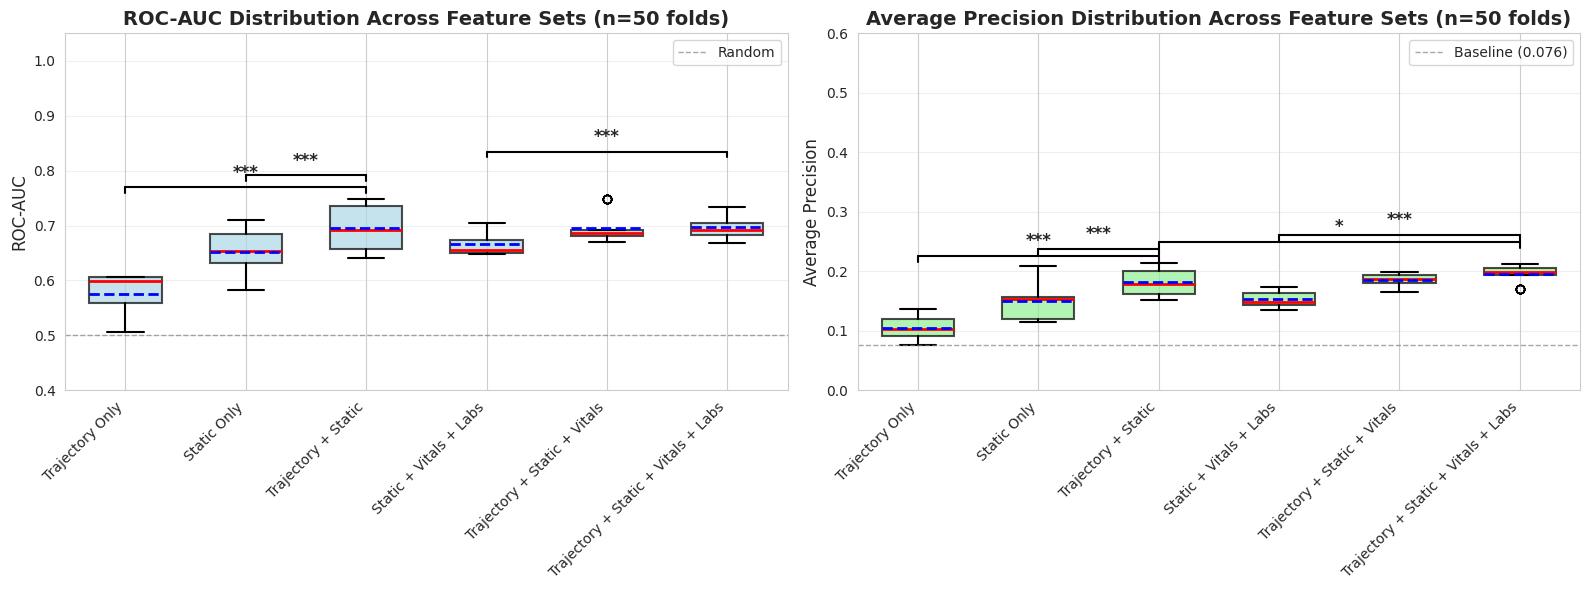


PAIRWISE STATISTICAL COMPARISONS (Wilcoxon Signed-Rank Test)
Comparison                                                   ROC-AUC p    Sig   AP p         Sig  
--------------------------------------------------------------------------------
Trajectory Only vs Trajectory + Static                       0.0000       ***   0.0000       ***  
  Effect size (Δ):                                           +0.1195        +0.0762
Static Only vs Trajectory + Static                           0.0000       ***   0.0000       ***  
  Effect size (Δ):                                           +0.0426        +0.0308
Trajectory + Static vs Trajectory + Static + Vitals + Labs   0.7897             0.0273       *    
  Effect size (Δ):                                           +0.0017        +0.0143
Static + Vitals + Labs vs Trajectory + Static + Vitals + Labs 0.0000       ***   0.0000       ***  
  Effect size (Δ):                                           +0.0305        +0.0429
Note: * p<0.05, ** p<0.01

In [ ]:
# Boxplot visualization with statistical significance testing (using shared utilities)
# Define pairwise comparisons
pairs_to_compare = [
    (0, 2),  # Trajectory Only vs Trajectory + Static
    (1, 2),  # Static Only vs Trajectory + Static
    (2, 5),  # Trajectory + Static vs Full model
    (3, 5),  # Static + Vitals + Labs vs Full model
]

feature_names = list(comparison_results.keys())
n_folds_total = len(comparison_results[feature_names[0]]['roc_auc'])

# Use shared utility function for boxplots with significance testing
fig, (ax1, ax2) = plot_boxplots_with_stats(
    comparison_results=comparison_results,
    outcome_df=outcome_df,
    target_col='target_weaning_success',
    pairs_to_compare=pairs_to_compare,
    n_folds_total=n_folds_total
)
plt.savefig('../../results/mimic/ventilator/model_comparison_boxplots_significance.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: model_comparison_boxplots_significance.png")
plt.show()

# Print detailed statistical comparisons using shared utility
print_statistical_comparisons(
    comparison_results=comparison_results,
    pairs_to_compare=pairs_to_compare
)

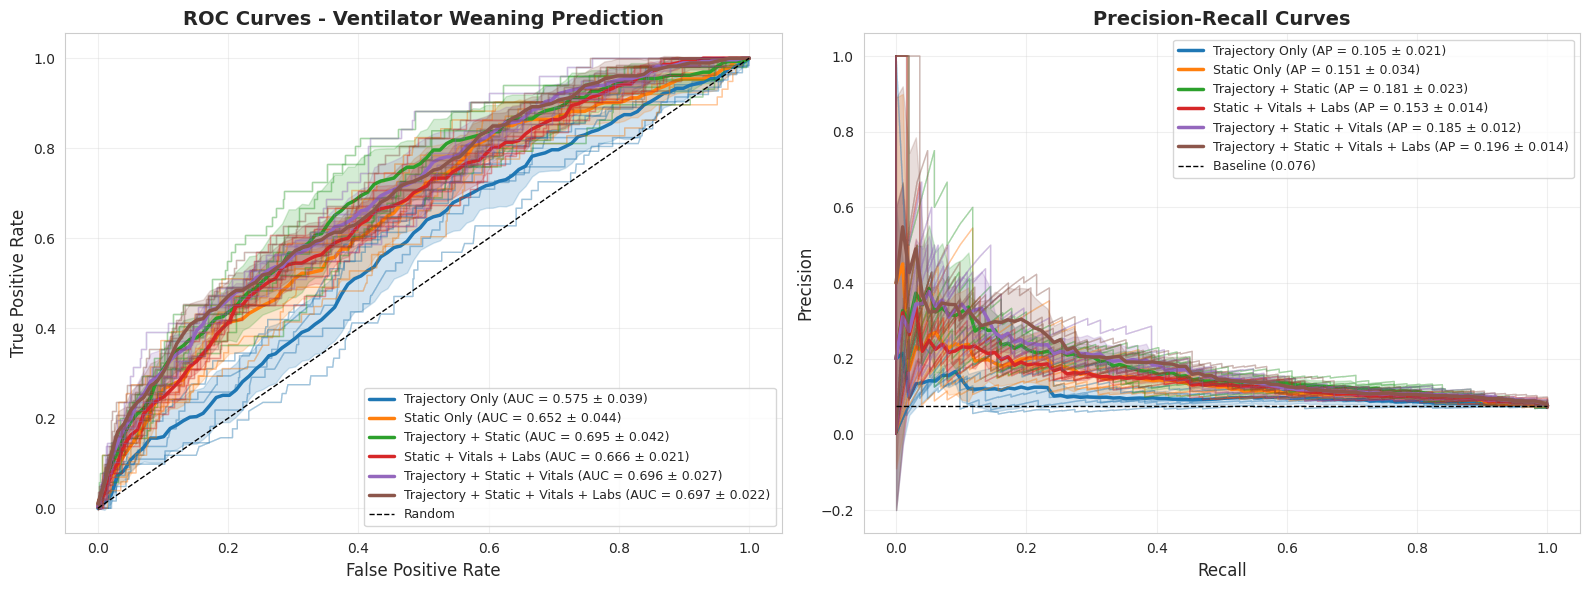

In [ ]:
# ROC & PR Curves - Using shared utility function
fig, (ax1, ax2) = plot_roc_pr_curves(
    comparison_results=comparison_results,
    outcome_df=outcome_df,
    target_col='target_weaning_success',
    color_scheme='tab10'
)

# Update titles for ventilator context
ax1.set_title('ROC Curves - Ventilator Weaning Prediction', fontsize=14, fontweight='bold')
ax2.set_title('Precision-Recall Curves - Ventilator Weaning Prediction', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../../results/mimic/ventilator/model_comparison_curves.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: model_comparison_curves.png")
plt.show()

In [51]:
print("\n✓ Ventilator weaning analysis complete!")
print(f"\n  Clinical Impact:")
print(f"    - Predicts successful weaning 48h in advance")
print(f"    - P/F ratio trajectory patterns identify readiness")
print(f"    - Reduces reintubation risk and ventilator-associated complications")


✓ Ventilator weaning analysis complete!

  Clinical Impact:
    - Predicts successful weaning 48h in advance
    - P/F ratio trajectory patterns identify readiness
    - Reduces reintubation risk and ventilator-associated complications
